In [36]:
import sys
sys.path.append("/home/pirie03/projects/aip-medilab/pirie03/NeedleMicroSeg")
from src.data.needle_fire_needle_mask_dataset import NeedleFireNeedleMaskDataset

import matplotlib.pyplot as plt
import numpy as np

In [37]:
# Dataset size 

DATA_ROOT = "/project/6106383/shared/2026-03-11_pwilson_needle-fire-needle-mask"
SPLITS_FILE = f"{DATA_ROOT}/optimum_patient_splits.json"

train_ds = NeedleFireNeedleMaskDataset(
    root=DATA_ROOT,
    split="train",
    splits_file=SPLITS_FILE
)

val_ds = NeedleFireNeedleMaskDataset(
    root=DATA_ROOT,
    split="val",
    splits_file=SPLITS_FILE
)

print(f"Number of training samples: {len(train_ds)}")
print(f"Number of validation samples: {len(val_ds)}")
print(f"Total samples: {len(train_ds) + len(val_ds)}")
for p in train_ds.samples[:10]:
    print(p.name)
print(f"Split Id: {train_ds.split_id}")

Number of training samples: 1345
Number of validation samples: 354
Total samples: 1699
OL-004-005.h5
OL-004-006.h5
OL-004-007.h5
OL-004-008.h5
OL-004-009.h5
OL-004-010.h5
OL-004-011.h5
OL-004-012.h5
OL-004-013.h5
OL-004-014.h5


AttributeError: 'NeedleFireNeedleMaskDataset' object has no attribute 'split_id'

In [ ]:
# Inspecting One Sample

sample = train_ds[0]

print("Keys available in a dataset sample:")
print(sample.keys())

print("\nShape of annotated needle-fire frame:")
print(sample["image"].shape)

print("\nShape of needle segmentation mask:")
print(sample["needle_mask"].shape)

print("\nFrame index where the needle annotation occurs:")
print(sample["needle_mask_annotation_index"])

print("\nCine ID for this sample:")
print(sample["cine_id"])

Keys available in a dataset sample:
dict_keys(['image', 'needle_mask', 'needle_mask_annotation_index', 'metadata', 'cine_id'])

Shape of annotated needle-fire frame:
(833, 1372)

Shape of needle segmentation mask:
(833, 1372)

Frame index where the needle annotation occurs:
39

Cine ID for this sample:
OL-004-005


In [38]:
# Inspect Full Cine Shape

ds_full = NeedleFireNeedleMaskDataset(
    root=DATA_ROOT,
    split="train",
    splits_file=SPLITS_FILE,
    return_full_cine=True
)

cine_sample = ds_full[0]

cine = cine_sample["image"]
annotation_index = cine_sample["needle_mask_annotation_index"]
last_frame_before_insertion = cine_sample["metadata"]["last_frame_before_needle_insertion"]

print("Shape of full cine clip (T, H, W):")
print(cine.shape)

print(f"\nNumber of frames in cine (T): {cine.shape[0]}")
print(f"Image height (H): {cine.shape[1]}")
print(f"Image width (W): {cine.shape[2]}")

print(f"\nFrame index containing needle annotation: {annotation_index}")
print(f"Last frame before needle insertion: {last_frame_before_insertion}")

Shape of full cine clip (T, H, W):
(60, 833, 1372)

Number of frames in cine (T): 60
Image height (H): 833
Image width (W): 1372

Frame index containing needle annotation: 39
Last frame before needle insertion: 22


In [ ]:
mins = []
maxs = []
means = []
stds = []

num_samples_to_check = 20

for i in range(num_samples_to_check):
    img = train_ds[i]["image"]
    
    mins.append(img.min())
    maxs.append(img.max())
    means.append(img.mean())
    stds.append(img.std())

print(f"Checked intensity statistics across {num_samples_to_check} samples")

print("\nGlobal minimum pixel value observed:", min(mins))
print("Global maximum pixel value observed:", max(maxs))

print("\nAverage image mean intensity:", np.mean(means))
print("Average image standard deviation:", np.mean(stds))

Checked intensity statistics across 20 samples

Global minimum pixel value observed: 0
Global maximum pixel value observed: 254

Average image mean intensity: 69.22409578991946
Average image standard deviation: 46.49373437700883


(np.float64(-0.5), np.float64(1371.5), np.float64(832.5), np.float64(-0.5))

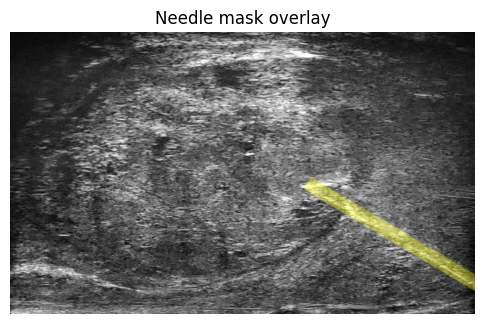

In [ ]:
# Visualize Needle Frame
 
img = sample["image"]
mask = sample["needle_mask"]

plt.figure(figsize=(6,6))

# base ultrasound image
plt.imshow(img, cmap="gray")

# create a yellow mask layer
yellow = np.zeros((*mask.shape, 4))  # RGBA
yellow[..., 0] = 1.0   # red
yellow[..., 1] = 1.0   # green
yellow[..., 3] = mask * 0.35  # alpha (transparency)

plt.imshow(yellow)

plt.title("Needle mask overlay")
plt.axis("off")

Visualizing frames around the needle-fire annotation index


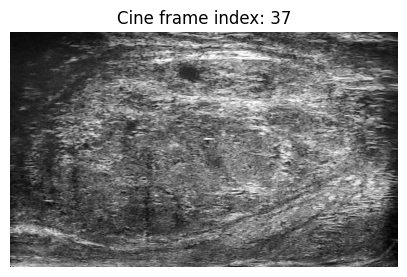

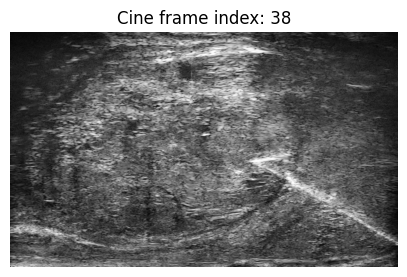

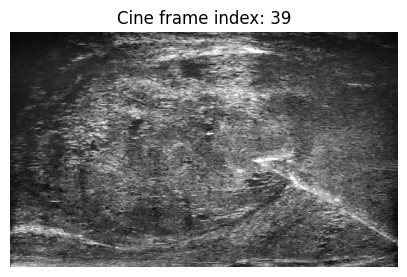

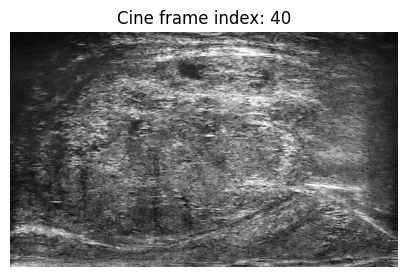

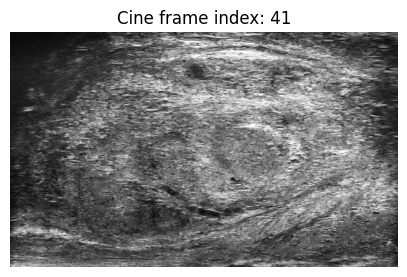

In [25]:
cine = cine_sample["image"]
idx = cine_sample["needle_mask_annotation_index"]

print("Visualizing frames around the needle-fire annotation index")

for i in range(idx - 2, idx + 3):
    if i < 0 or i >= cine.shape[0]:
        continue
        
    plt.figure(figsize=(5,5))
    plt.imshow(cine[i], cmap="gray")
    plt.title(f"Cine frame index: {i}")
    plt.axis("off")